In [55]:
'''
prompt:
Escreva codigo python que le todos os arquivos CSV disponiveis na pasta data/model-runs. 
O nome de cada arquivo CSV está no formato gemini-2.5-flash_answers.csv, em que tudo que vem antes de  "_answers.csv" é o nome do modelo. 

Leia cada arquivo CSV com o pandas. 
Cada linha do arquivo é uma questão da OAB que o modelo resolveu. 
Calcule o número de respostas certas comparando se "alternativa" == "correct". 
Crie um df em que cada row é um modelo, com a nota total e a nota percentual.

'''

import pandas as pd
import os
import glob
import re

# Caminho da pasta com os arquivos CSV
language = "turkish"
folder_path = f'../data/processed/model-runs/{language}'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_firac*.csv'))

# Lista para guardar os resultados de cada modelo
model_results = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_firac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        firac = match.group(2)


    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if 'alternativa' not in df.columns or 'correct' not in df.columns:
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Conta quantas respostas estão corretas
    total_questions = len(df)
    correct_answers = (df['alternativa'] == df['correct']).sum()
    percentage = correct_answers / total_questions * 100

    # Adiciona os resultados à lista
    model_results.append({
        'model': model_name,
        'firac': firac,
        'questões': total_questions,
        'acertos': correct_answers,
        'accuracy': round(percentage, 2)
    })

# Cria um DataFrame com os resultados
model_results_df = pd.DataFrame(model_results)

# Ordena do maior para o menor percentual de acertos
model_results_df = model_results_df.sort_values(by=['model', 'accuracy'], ascending=False)

model_results_df.head(300)




,model,firac,questões,acertos,accuracy
17,gemini-2.5-pro,FIRAC,1,1,100.0
18,gemini-2.5-pro,FIRA_,1,1,100.0
19,gemini-2.5-pro,FIR__,1,1,100.0
20,gemini-2.5-pro,FI___,1,1,100.0
21,gemini-2.5-pro,F____,2,2,100.0
6,gemini-2.5-flash-lite-preview-06-17,FIRAC,1,1,100.0
7,gemini-2.5-flash-lite-preview-06-17,FIRA_,1,1,100.0
8,gemini-2.5-flash-lite-preview-06-17,FIR__,1,1,100.0
9,gemini-2.5-flash-lite-preview-06-17,FI___,1,0,0.0
10,gemini-2.5-flash-lite-preview-06-17,F____,1,0,0.0


In [56]:
import pandas as pd
import os
import glob
import re

def read_all_dfs():
    # Caminho da pasta com os arquivos CSV
    folder_path = f'../data/processed/model-runs/{language}'
    csv_files = glob.glob(os.path.join(folder_path, '*_answers_firac*.csv'))

    # Lista para guardar os resultados de cada questão
    question_results = []

    for filepath in csv_files:
        # Extrai o nome do modelo a partir do nome do arquivo
        filename = os.path.basename(filepath)
        match = re.match(r'(.+)_answers_firac-(.*)\.csv$', filename)
        if match:
            model_name = match.group(1)
            irac = match.group(2)

        # Lê o CSV com pandas
        df = pd.read_csv(filepath)

        # Adiciona colunas extras
        df["model_name"] = model_name
        df["firac"] = irac

        # Armazena na lista
        question_results.append(df)
        
    # Concatena todos os DataFrames em um único
    final_df = pd.concat(question_results, ignore_index=True)

    # Reordena colunas: model_name e irac primeiro
    cols = ["model_name", "firac"] + [c for c in final_df.columns if c not in ["model_name", "firac"]]
    final_df = final_df[cols]

    return final_df


In [57]:
full_df = read_all_dfs()
full_df.head()

,model_name,firac,pdf_filename,materia,prova,questao,question_id,enunciado,A,B,C,D,resposta_completa,alternativa,correct,response_time_seconds,language,prompt,rule_count
0,gemini-2.0-flash,FIRAC,oab-28.pdf,ÉTICA PROFISSIONAL,XXIX,273,oab-28.pdf-273,Júnior hukuk mezunudur. Hukuk fakültesinden al...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapabilirdi. Uygul...,Júnior stajyer olarak görev yapabilirdi. Uygul...,cevap: D\n,D,D,1.030586,Portekizce,Sınav sorusunu aşağıda çözünüz.\nCevabı şu for...,3.0
1,gemini-2.0-flash,FIRA_,oab-28.pdf,ÉTICA PROFISSIONAL,XXIX,273,oab-28.pdf-273,Júnior hukuk mezunudur. Hukuk fakültesinden al...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapabilirdi. Uygul...,Júnior stajyer olarak görev yapabilirdi. Uygul...,cevap: D\n,D,D,1.000907,Portekizce,Sınav sorusunu aşağıda çözünüz.\nCevabı şu for...,3.0
2,gemini-2.0-flash,FIR__,oab-28.pdf,ÉTICA PROFISSIONAL,XXIX,273,oab-28.pdf-273,Júnior hukuk mezunudur. Hukuk fakültesinden al...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapabilirdi. Uygul...,Júnior stajyer olarak görev yapabilirdi. Uygul...,cevap: D\n,D,D,1.453029,Portekizce,Sınav sorusunu aşağıda çözünüz.\nCevabı şu for...,3.0
3,gemini-2.0-flash,FI___,oab-28.pdf,ÉTICA PROFISSIONAL,XXIX,273,oab-28.pdf-273,Júnior hukuk mezunudur. Hukuk fakültesinden al...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapabilirdi. Uygul...,Júnior stajyer olarak görev yapabilirdi. Uygul...,cevap: C\n,C,D,1.647033,Portekizce,Sınav sorusunu aşağıda çözünüz.\nCevabı şu for...,3.0
4,gemini-2.0-flash,F____,oab-28.pdf,ÉTICA PROFISSIONAL,XXIX,273,oab-28.pdf-273,Júnior hukuk mezunudur. Hukuk fakültesinden al...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapamazdı ve bu ha...,Júnior stajyer olarak görev yapabilirdi. Uygul...,Júnior stajyer olarak görev yapabilirdi. Uygul...,cevap: C,C,D,1.166351,Portekizce,Sınav sorusunu aşağıda çözünüz.\nCevabı şu for...,3.0


In [58]:
full_df[full_df.question_id == 'oab-336.pdf-151']

,model_name,firac,pdf_filename,materia,prova,questao,question_id,enunciado,A,B,C,D,resposta_completa,alternativa,correct,response_time_seconds,language,prompt,rule_count


In [59]:
def calculate_consistency(matrix):
    """
    Calcula o score de consistência de uma matriz binária.

    A regra é:
    - Na horizontal: andando para a direita, um 1 nunca pode virar 0.
    - Na vertical: andando para baixo, um 1 nunca pode virar 0.

    Retorna:
        consistency (float): score entre 0 e 1
    """
    arr = matrix.fillna(0).astype(int).values
    n_rows, n_cols = arr.shape

    total_checks, violations = 0, 0

    # checa horizontal
    for i in range(n_rows):
        for j in range(n_cols - 1):
            total_checks += 1
            if arr[i, j] == 1 and arr[i, j+1] == 0:
                violations += 1

    # checa vertical
    for i in range(n_rows - 1):
        for j in range(n_cols):
            total_checks += 1
            if arr[i, j] == 1 and arr[i+1, j] == 0:
                violations += 1

    return 1 - (violations / total_checks if total_checks > 0 else 0)


def extract_question_matrix(question_id, final_df):
    """
    Gera uma matriz de 1s e 0s com acerto/erro da questão por (modelo, irac),
    ordenando linhas e colunas pela acurácia média global.

    Retorna:
        matrix (pd.DataFrame): matriz binária
        consistency (float): score entre 0 e 1
    """
    # ---- calcula acurácia global ----
    final_df = final_df.copy()
    final_df['is_correct'] = (final_df['alternativa'] == final_df['correct']).astype(int)

    model_acc = final_df.groupby('model_name')['is_correct'].mean().sort_values(ascending=True)
    irac_acc = final_df.groupby('firac')['is_correct'].mean().sort_values(ascending=True)

    # ---- filtra questão específica ----
    df_q = final_df[final_df['question_id'] == question_id].copy()

    # cria matriz
    matrix = df_q.pivot_table(
        index="model_name",
        columns="firac",
        values="is_correct",
        aggfunc="first"
    )

    # ---- reordena linhas e colunas pela acurácia média ----
    matrix = matrix.loc[matrix.index.intersection(model_acc.index)]
    matrix = matrix.loc[model_acc.index]
    matrix = matrix[irac_acc.index.intersection(matrix.columns)]

    # ---- calcula consistência ----
    consistency = calculate_consistency(matrix)

    return matrix, consistency


In [60]:
def get_eligible_questions(full_df):
    """
    Retorna uma lista de question_id que foram avaliadas para todos os pares (model_name, firac).
    """
    # conjunto de todos os pares possíveis
    all_pairs = set(full_df[['model_name', 'firac']].drop_duplicates().itertuples(index=False, name=None))
    n_pairs = len(all_pairs)

    # conta pares únicos por questão
    pair_counts = (
        full_df.groupby('question_id')[['model_name', 'firac']]
        .apply(lambda x: len(set(x.itertuples(index=False, name=None))))
    )

    # mantém apenas questões com todos os pares
    eligible_questions = pair_counts[pair_counts == n_pairs].index.tolist()

    return eligible_questions


eligeble_questions = get_eligible_questions(full_df)
print(len(eligeble_questions))

1


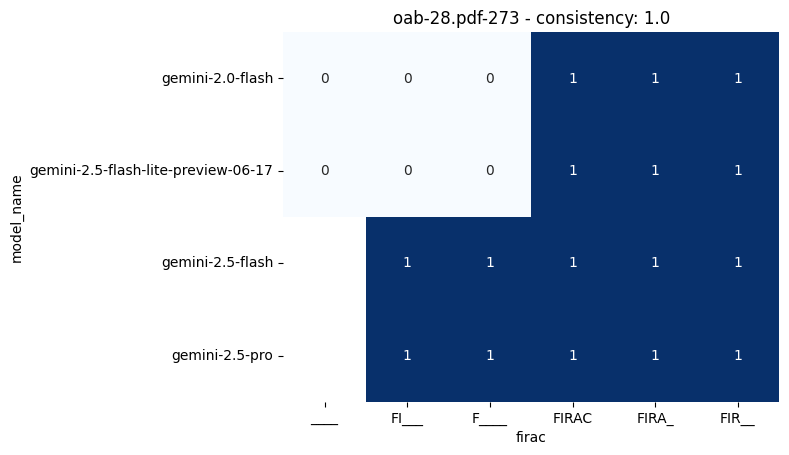

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

qid = "oab-28.pdf-273"
#qid = "oab-150.pdf-061"

matrix, consistency = extract_question_matrix(qid, full_df)
sns.heatmap(matrix, annot=True, cmap="Blues", cbar=False)
plt.title(f"{qid} - consistency: {consistency}")
plt.show()

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_question_matrices(final_df):
    """
    Plota uma matriz para cada question_id, ordenados pela acurácia média da questão.
    """
    # calcula acurácia média de cada questão
    final_df = final_df.copy()
    final_df['is_correct'] = (final_df['alternativa'] == final_df['correct']).astype(int)
    question_acc = final_df.groupby('question_id')['is_correct'].mean().sort_values(ascending=False)

    # plota cada questão
    for qid in get_eligible_questions(final_df):
        matrix, consistency = extract_question_matrix(qid, final_df)

        print('qid', qid, consistency)
        #print(matrix)
        #print()

        #plt.figure(figsize=(8, 6))
        #sns.heatmap(matrix, annot=True, cmap="Blues", cbar=False, linewidths=0.5, linecolor="gray")
        #plt.title(f"Questão {qid} (Acurácia média: {question_acc[qid]:.2f})")
        #plt.ylabel("Modelos")
        #plt.xlabel("IRAC")
        #plt.tight_layout()
        #plt.show()

# Exemplo: gera plots de todas as questões
plot_all_question_matrices(full_df)


qid oab-28.pdf-273 1.0


In [63]:
import pandas as pd
import os
import glob
import re

# Caminho da pasta com os arquivos CSV
folder_path = '../data/processed/model-runs/portuguese'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_firac*.csv'))

# Lista para guardar os resultados de cada questão
question_results = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_firac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        firac = match.group(2)

    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if 'alternativa' not in df.columns or 'correct' not in df.columns or 'question_id' not in df.columns:
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Para cada questão, calcula se a resposta está correta
    for _, row in df.iterrows():
        is_correct = int(row['alternativa'] == row['correct'])
        question_results.append({
            'question_id': row['question_id'],
            'materia': row['materia'],
            'firac': firac,
            'model': model_name,
            'acertos': is_correct
        })

# Cria DataFrame com os resultados
question_results_df = pd.DataFrame(question_results)

# Calcula métricas agregadas por questão
question_results_df = question_results_df.groupby(['question_id', 'materia', 'firac']).agg(
    acertos_total=('acertos', 'sum'),
    total_modelos=('acertos', 'count'),
    accuracy=('acertos', 'mean')
).reset_index()

# Ordena por question_id e accuracy
question_results_df = question_results_df.sort_values(by=['question_id', 'accuracy'], ascending=False)

question_results_df.head(300)


,question_id,materia,firac,acertos_total,total_modelos,accuracy
15,oab-336.pdf-151,PROCESSO DO TRABALHO,FIRA_,3,3,1.000000
16,oab-336.pdf-151,PROCESSO DO TRABALHO,FIR__,3,3,1.000000
14,oab-313.pdf-162,DIREITO DO TRABALHO,FIR__,1,1,1.000000
8,oab-28.pdf-273,ÉTICA PROFISSIONAL,FIRAC,4,4,1.000000
9,oab-28.pdf-273,ÉTICA PROFISSIONAL,FIRA_,4,4,1.000000
10,oab-28.pdf-273,ÉTICA PROFISSIONAL,FIR__,3,4,0.750000
7,oab-28.pdf-273,ÉTICA PROFISSIONAL,FIL__,2,3,0.666667
12,oab-28.pdf-273,ÉTICA PROFISSIONAL,F____,2,4,0.500000
11,oab-28.pdf-273,ÉTICA PROFISSIONAL,FI___,1,3,0.333333
13,oab-28.pdf-273,ÉTICA PROFISSIONAL,____,1,3,0.333333


In [64]:
question_results_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 15 to 6
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   question_id    17 non-null     object 
 1   materia        17 non-null     object 
 2   firac          17 non-null     object 
 3   acertos_total  17 non-null     int64  
 4   total_modelos  17 non-null     int64  
 5   accuracy       17 non-null     float64
dtypes: float64(1), int64(2), object(3)
memory usage: 952.0+ bytes


In [65]:
import pandas as pd

# Cria pivot table
question_accuracy_pivot = question_results_df.pivot(
    index=['question_id', 'materia'],
    columns='firac',
    values='accuracy'
)

# Calcula a média de acurácia por coluna e ordena as colunas
col_order = question_accuracy_pivot.mean().sort_values(ascending=True).index
question_accuracy_pivot = question_accuracy_pivot[col_order].sort_values(by='____', ascending=False)

question_accuracy_df = question_accuracy_pivot.dropna()

question_accuracy_df.tail()


,firac,____,FI___,F____,FIL__,FIR__,FIRAC,FIRA_
question_id,materia,,,,,,,
oab-196.pdf-060,DIREITO DO CONSUMIDOR,0.666667,1.000000,1.0,1.000000,1.00,1.0,1.0
oab-28.pdf-273,ÉTICA PROFISSIONAL,0.333333,0.333333,0.5,0.666667,0.75,1.0,1.0


In [66]:
question_accuracy_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2 entries, ('oab-196.pdf-060', 'DIREITO DO CONSUMIDOR') to ('oab-28.pdf-273', 'ÉTICA PROFISSIONAL')
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ____    2 non-null      float64
 1   FI___   2 non-null      float64
 2   F____   2 non-null      float64
 3   FIL__   2 non-null      float64
 4   FIR__   2 non-null      float64
 5   FIRAC   2 non-null      float64
 6   FIRA_   2 non-null      float64
dtypes: float64(7)
memory usage: 640.0+ bytes


In [67]:
import pandas as pd

# Cria uma coluna temporária 'materia_temp' com o segundo nível do MultiIndex
question_accuracy_df = question_accuracy_df.copy()
question_accuracy_df['materia_temp'] = [idx[1] for idx in question_accuracy_df.index]

# Agrupa por matéria e calcula a média de todas as colunas de acurácia
materia_df = question_accuracy_df.groupby('materia_temp')[['____', 'FI___', 'F____', 'FIL__', 'FIR__', 'FIRAC', 'FIRA_']].mean()

# Mostra o resultado
materia_df.sort_values(by='____')


firac,____,FI___,F____,FIL__,FIR__,FIRAC,FIRA_
materia_temp,,,,,,,
ÉTICA PROFISSIONAL,0.333333,0.333333,0.5,0.666667,0.75,1.0,1.0
DIREITO DO CONSUMIDOR,0.666667,1.000000,1.0,1.000000,1.00,1.0,1.0


In [68]:
question_accuracy_df.columns

Index(['____', 'FI___', 'F____', 'FIL__', 'FIR__', 'FIRAC', 'FIRA_',
       'materia_temp'],
      dtype='object', name='firac')

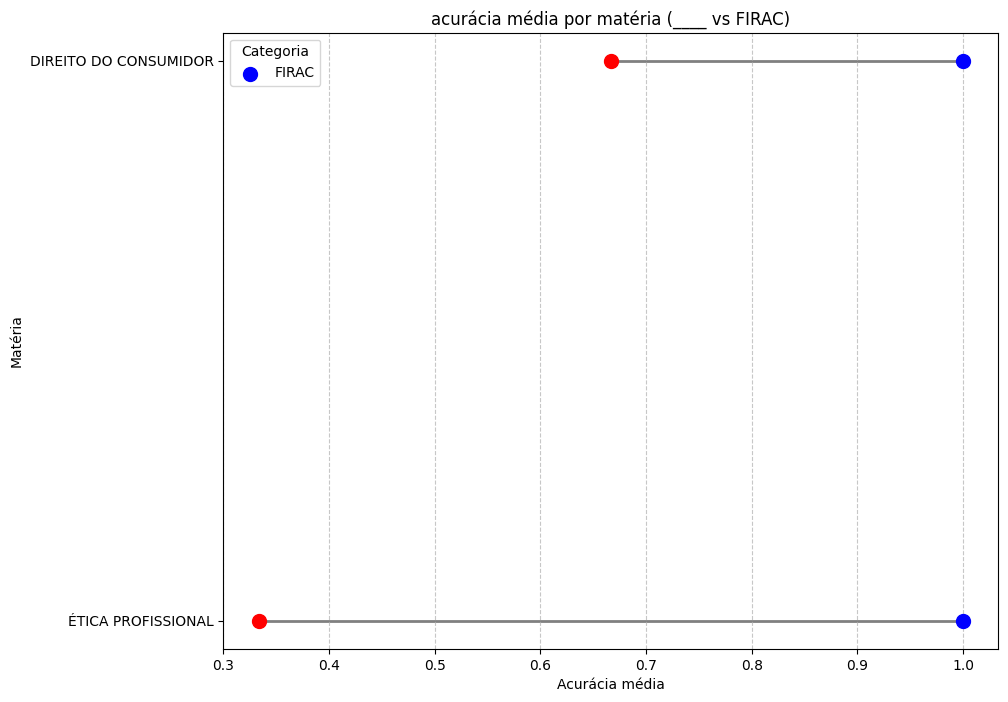

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

source_category = '____'
target_category = 'FIRAC'

# Cria coluna temporária com a matéria (segundo elemento da tupla do Index)
question_accuracy_df = question_accuracy_df.copy()
question_accuracy_df['materia_temp'] = [idx[1] for idx in question_accuracy_df.index]

# Calcula a média da acurácia por matéria
materia_means = question_accuracy_df.groupby('materia_temp')[[source_category, target_category]].mean().reset_index()
materia_means = materia_means.sort_values(by=source_category, ascending=True)

# Plot do gráfico pirulito
plt.figure(figsize=(10, 8))

# Adiciona pontos para legenda apenas
plt.scatter([], [], color='red', s=100, label=source_category)
plt.scatter([], [], color='blue', s=100, label=target_category)

# Plot cada linha e os pontos
for i, row in materia_means.iterrows():
    plt.plot([row[source_category], row[target_category]], [row['materia_temp'], row['materia_temp']], color='grey', lw=2, zorder=1)
    plt.scatter(row[source_category], row['materia_temp'], color='red', s=100, zorder=2)
    plt.scatter(row[target_category], row['materia_temp'], color='blue', s=100, zorder=2)

plt.xlabel("Acurácia média")
plt.ylabel("Matéria")
plt.title(f"acurácia média por matéria ({source_category} vs {target_category})")
plt.legend(title='Categoria')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supondo que seu DataFrame seja model_results_df

# Ordenar categorias de X e Y pela média de accuracy
irac_order = model_results_df.groupby('firac')['accuracy'].mean().sort_values().index
model_order = model_results_df.groupby('model')['accuracy'].mean().sort_values().index

# Criar pivot table
heatmap_data = model_results_df.pivot_table(
    index='model',
    columns='firac',
    values='accuracy'
)

# Reordenar linhas e colunas
heatmap_data = heatmap_data.loc[model_order, irac_order]

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis")
plt.title("Heatmap de Accuracy por Model e IRAC")
plt.xlabel("IRAC")
plt.ylabel("Model")
plt.show()


KeyError: 'irac'

In [ ]:
import pandas as pd
import os
import glob
import re
import json

# Caminho da pasta com os arquivos CSV
folder_path = '../data/processed/model-runs/'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_irac*.csv'))

# Lista para guardar todos os dados juntos
all_data = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_irac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        irac = match.group(2)

    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if not {'alternativa', 'correct', 'question_id'}.issubset(df.columns):
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Adiciona colunas de metadados
    df['modelo'] = model_name
    df['irac'] = irac
    df['acertou'] = df['alternativa'] == df['correct']


    # Armazena os dados
    all_data.append(df)

# Junta todos os dados em um único DataFrame
questions_df = pd.concat(all_data, ignore_index=True)

questions_df.head()

,pdf_filename,materia,prova,questao,question_id,enunciado,A,B,C,D,resposta_completa,alternativa,correct,prompt,irac,rule_count,modelo,acertou
0,oab-5.pdf,ÉTICA PROFISSIONAL,V,43,oab-5.pdf-043,No julgamento da ação envolvendo Manoel e Joaq...,"Art. 7º, inciso VII do Estatuto da OAB; Art. 7...","Art. 8º, II da Lei nº 8.096/94; Art. 23 do Reg...","Art. 30 do CEDOAB/2015; Art. 30, § 3º, do CEDO...","Art. 7º, inciso XIX, do EAOAB; Sigilo Profissi...",resposta: A\n,A,A,"Para a questão do exame da ordem a OAB abaixo,...",G,5.0,gemini-1.5-flash-8b,True
1,oab-52.pdf,DIREITO CONSTITUCIONAL,IX,60,oab-52.pdf-060,João ingressa com ação individual buscando a r...,"Art. 52, X da Constituição Federal de 1988; Ar...","Art. 5º, inciso VII da Constituição Federal de...","Art. 12, I, c, da Constituição Federal de 1988...","Art. 50, § 2º da Constituição Federal de 1988;...",resposta: A\n,A,A,"Para a questão do exame da ordem a OAB abaixo,...",G,7.0,gemini-1.5-flash-8b,True
2,oab-204.pdf,DIREITO EMPRESARIAL,IV,61,oab-204.pdf-061,É uma cláusula acessória ao contrato de comiss...,Art. 698 do Código Civil; Art. 521 do Código C...,Requisitos para a execução de duplicata não ac...,Art. 999 do Código Civil; Art. 1.027 do Código...,"Art. 1.028, inciso I, do Código Civil; Art. 1....",resposta: A\n,A,A,"Para a questão do exame da ordem a OAB abaixo,...",G,5.0,gemini-1.5-flash-8b,True
3,oab-150.pdf,DIREITO AMBIENTAL,XXXII,61,oab-150.pdf-061,"A sociedade empresária Alfa opera, com regular...","Lei Complementar nº 140/2011, Art. 5º","Art. 24, I da Constituição Federal de 1988; Ar...",Princípio da Competência Comum em matéria ambi...,"Art. 15, II da Lei Complementar nº 140/2011",resposta: C\n,C,A,"Para a questão do exame da ordem a OAB abaixo,...",G,1.0,gemini-1.5-flash-8b,False
4,oab-56.pdf,DIREITO CONSTITUCIONAL,III,98,oab-56.pdf-098,O controle externo financeiro da União e das e...,"Art. 71, I, da Constituição Federal de 1988; A...","Art. 52, X da Constituição Federal de 1988; Ar...","Art. 50, § 2º da Constituição Federal de 1988;...","Art. 12, I, c, da Constituição Federal de 1988...",resposta: A\n,A,A,"Para a questão do exame da ordem a OAB abaixo,...",G,4.0,gemini-1.5-flash-8b,True


In [ ]:
questions_df.columns

Index(['pdf_filename', 'materia', 'prova', 'questao', 'question_id',
       'enunciado', 'A', 'B', 'C', 'D', 'resposta_completa', 'alternativa',
       'correct', 'prompt', 'irac', 'rule_count', 'modelo', 'acertou'],
      dtype='object')

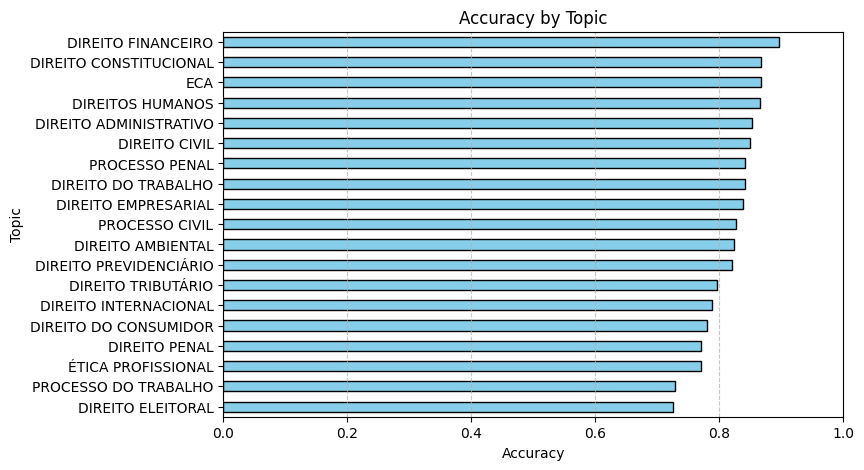

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# exemplo de DataFrame
# questions_df = pd.DataFrame({
#     'materia': ['Matemática', 'História', 'Matemática', 'Física', 'História', 'Física'],
#     'acertou': [True, False, True, True, True, False]
# })

# calcular acurácia por matéria
accuracy_by_materia = questions_df.groupby("materia")["acertou"].mean().sort_values()

# plotar histograma horizontal
plt.figure(figsize=(8, 5))
accuracy_by_materia.plot(kind="barh", color="skyblue", edgecolor="black")

plt.xlabel("Accuracy")
plt.ylabel("Topic")
plt.title("Accuracy by Topic")
plt.xlim(0, 1)  # porque acurácia vai de 0 a 1
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()


In [ ]:
# Calcula a acurácia e média de rule_count por question_id e materia
accuracy_by_question_df = (
    questions_df.groupby(['question_id', 'materia'])
    .agg(acurácia=('acertou', 'mean'),
         rule_count=('rule_count', 'mean'))
    .reset_index()
    .sort_values(by='acurácia', ascending=False)
)

# Exibe as 100 últimas linhas (menor acurácia)
accuracy_by_question_df.tail(100)


,question_id,materia,acurácia,rule_count
38,oab-152.pdf-084,DIREITO AMBIENTAL,0.857143,1.0
139,oab-333.pdf-114,PROCESSO DO TRABALHO,0.857143,3.0
122,oab-297.pdf-006,DIREITO DO TRABALHO,0.857143,2.0
125,oab-304.pdf-071,DIREITO DO TRABALHO,0.852941,4.0
111,oab-282.pdf-105,PROCESSO PENAL,0.851852,3.0
...,...,...,...,...
171,oab-77.pdf-009,DIREITOS HUMANOS,0.483871,1.0
8,oab-110.pdf-119,DIREITO TRIBUTÁRIO,0.448276,2.0
99,oab-251.pdf-054,DIREITO PENAL,0.428571,7.0
101,oab-263.pdf-173,DIREITO PENAL,0.333333,4.0


In [ ]:

# Contagem e porcentagem de alternativas por questão
counts = questions_df.groupby(['question_id', 'alternativa']).size().reset_index(name='count')
total_per_question = counts.groupby('question_id')['count'].transform('sum')
counts['percentage'] = (counts['count'] / total_per_question) * 100

# Pivot com alternativas como colunas
percentage_df = counts.pivot(index='question_id', columns='alternativa', values='percentage').fillna(0)

# Adiciona coluna 'correct'
correct_values = questions_df.groupby('question_id')['correct'].first()
percentage_df = percentage_df.merge(correct_values, on='question_id').reset_index()


percentage_df.head()

,question_id,A,B,C,D,correct
0,oab-1.pdf-003,13.888889,0.000000,13.888889,72.222222,D
1,oab-100.pdf-014,27.586207,0.000000,0.000000,72.413793,A
2,oab-100.pdf-019,7.500000,0.000000,10.000000,82.500000,A
3,oab-103.pdf-048,12.765957,0.000000,0.000000,87.234043,A
4,oab-104.pdf-055,83.333333,6.666667,10.000000,0.000000,A


In [ ]:
analysis_df = percentage_df.merge(accuracy_by_question_df, on='question_id', how='inner')
analysis_df = analysis_df.sort_values(by='acurácia', ascending=False)

analysis_df

,question_id,A,B,C,D,correct,materia,acurácia,rule_count
43,oab-157.pdf-052,14.285714,0.000000,85.714286,0.000000,A,DIREITO CIVIL,1.000000,4.0
55,oab-181.pdf-001,14.285714,0.000000,85.714286,0.000000,A,ECA,1.000000,8.0
23,oab-135.pdf-168,100.000000,0.000000,0.000000,0.000000,A,DIREITO ADMINISTRATIVO,1.000000,5.0
170,oab-73.pdf-275,14.285714,0.000000,0.000000,85.714286,A,DIREITO CONSTITUCIONAL,1.000000,4.0
163,oab-59.pdf-133,14.893617,85.106383,0.000000,0.000000,A,DIREITO CONSTITUCIONAL,1.000000,5.0
...,...,...,...,...,...,...,...,...,...
171,oab-77.pdf-009,51.724138,27.586207,0.000000,20.689655,A,DIREITOS HUMANOS,0.483871,1.0
8,oab-110.pdf-119,48.148148,51.851852,0.000000,0.000000,A,DIREITO TRIBUTÁRIO,0.448276,2.0
99,oab-251.pdf-054,0.000000,100.000000,0.000000,0.000000,B,DIREITO PENAL,0.428571,7.0
101,oab-263.pdf-173,0.000000,0.000000,66.666667,33.333333,D,DIREITO PENAL,0.333333,4.0


<Figure size 1000x600 with 0 Axes>

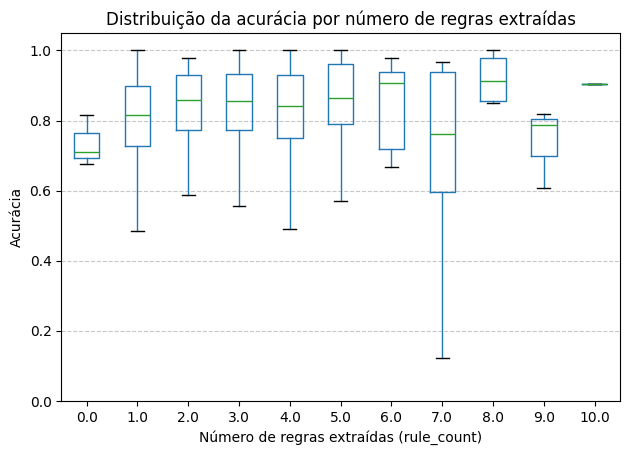

In [ ]:
import matplotlib.pyplot as plt

# Plot de boxplot diretamente a partir do DataFrame original
plt.figure(figsize=(10, 6))
accuracy_by_question_df.boxplot(
    column='acurácia',
    by='rule_count',
    grid=False,
    showfliers=False  # oculta outliers, opcional
)

plt.xlabel('Número de regras extraídas (rule_count)')
plt.ylabel('Acurácia')
plt.title('Distribuição da acurácia por número de regras extraídas')
plt.suptitle('')  # Remove o título automático extra do pandas
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

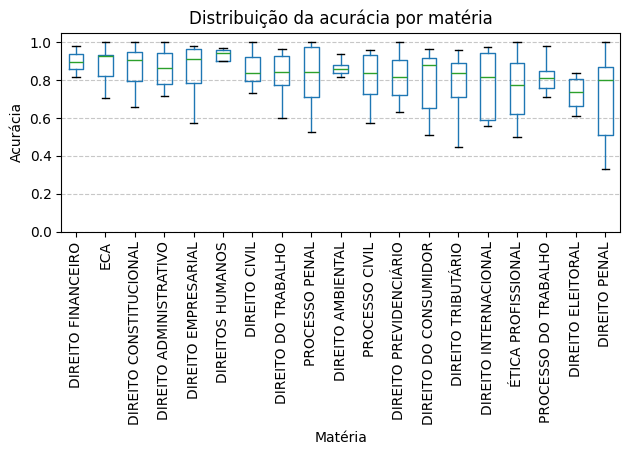

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calcula a ordem das matérias pela média da acurácia (maior para menor)
materia_order = (
    accuracy_by_question_df.groupby('materia')['acurácia']
    .mean()
    .sort_values(ascending=False)
    .index
)

# Reordena o DataFrame conforme essa ordem
accuracy_sorted_df = accuracy_by_question_df.copy()
accuracy_sorted_df['materia'] = pd.Categorical(
    accuracy_sorted_df['materia'],
    categories=materia_order,
    ordered=True
)

# Plot do boxplot
plt.figure(figsize=(10, 6))
accuracy_sorted_df.boxplot(
    column='acurácia',
    by='materia',
    grid=False,
    showfliers=False  # oculta outliers
)

plt.xlabel('Matéria')
plt.ylabel('Acurácia')
plt.title('Distribuição da acurácia por matéria')
plt.suptitle('')  # Remove título automático extra do pandas
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gira os labels do eixo X para vertical
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Função para calcular DI de uma questão
def discrimination_index(df, top_pct=0.15):
    di_list = []

    # Calcula a pontuação total de cada aluno (soma de acertos)
    df['total_acertos'] = df.groupby('pdf_filename')['acertou'].transform('sum')

    # Para cada questão
    for qid, group in df.groupby('question_id'):
        # Ordena alunos pelo total de acertos
        group_sorted = group.sort_values('total_acertos', ascending=False)
        n = len(group_sorted)
        n_top = max(1, int(top_pct * n))   # garante pelo menos 1 aluno
        n_bottom = n_top

        # Divide em top e bottom
        top_group = group_sorted.head(n_top)
        bottom_group = group_sorted.tail(n_bottom)

        # Calcula proporção de acertos
        p_top = top_group['acertou'].mean()
        p_bottom = bottom_group['acertou'].mean()

        # Discrimination Index
        di = p_top - p_bottom
        di_list.append({'question_id': qid, 'discrimination_index': di})

    return pd.DataFrame(di_list)

# Aplica a função
di_df = discrimination_index(full_df)

# Visualiza as primeiras linhas
di_df.sort_values(by='discrimination_index', ascending=False)

di_df['discrimination_index'].mean()


KeyError: 'Column not found: acertou'